# Problem 7.3

**Integrated Energy Grids**


**Problem 7.3**

**Assume the gas transport system that is shown in Figure 2. Gas can be injected in Node 1 at a marginal price of 10 EUR/kg or at Node 5 at 15 EUR/kg. There is a demand of 400 kg/s in Node 4. Assume pressure at node 4 is to 50 bar. Finally, Node 2-3 represents a pumping station where gas pressure can be increased by $k_{23}$=1.2 at a cost that is proportional to the mass flow $m_{23}$ by a constant $o_{23}$ =5 EUR/kg.**

**To calculate the speed of sound in gas $c$, assume the universal gas constant $R$=8.314 J/molK, the molar mass of methane $M$=16 g/mol, compression factor $Z$=1.31, and temperature T=25$^{\circ}$C. Assume the diameter of the pipelines is $D$ = 1000 mm, the length $L_{12}$=$L_{34}$=$L_{45}$=1000 m, and calculate the Darcy friction  coefficient $f_{D}$ assuming fully-turbulent flow and roughness $\epsilon$=0.001m.**

**(a) Write the equations of the optimization problem that minimizes the total system cost and use the Weymouth equation to represent pressure drop in the pipelines as a function of the mass flow $m_{ij}$.**


We define the pressure at differet node as $\pi_i$ and the mass flow at different pipes as $m_{ij}$
We have 9 variables ($m_{12}$, $m_{23}$, $m_{34}$, $m_{45}$, $\pi_1$, $\pi_2$, $\pi_3$, $\pi_4$, $\pi_5$).

We impose the energy balance constraint in nodes 1, 4 and 5, and the pipeline mass conservation and Weymouth equation in pipelines 12, 34 and 45.

\begin{alignat*}{3}
\min_{x,y} \quad & o_1g_1 + o_5g_5 +o_{23}m_{23} & \\
\text{s.t.} \quad & g_{1}=m_{12}  \\
\quad & -d_{4}=-m_{34}+m_{45}  \\
\quad & g_{5}=-m_{45}  \\
\quad & m_{12}=m_{23}  \\
\quad & m_{23}=m_{34}  \\
\quad & m_{34}=m_{45}  \\
\quad & \pi_{3}=k_{23}\pi_{2}  \\
\quad & \pi_{1}^2-\pi_{2}^2=a_{12}m_{12} |m_{12} | \\
\quad & \pi_{3}^2-\pi_{4}^2=a_{34}m_{34} |m_{34} | \\
\quad & \pi_{4}^2-\pi_{5}^2=a_{45}m_{45} |m_{34} | \\
\end{alignat*}


where the coefficients $a_{ij}=\frac{Lf^Dc^2}{DA^2}$ depend on the physical properties of the pipelines and the methane gas.

**(b) Use gurobipy to formulate and solve the problem. Solve the problem for two extra cases of : $o_{23}$ =1 EUR/kg and $o_{23}$ =10 EUR/kg and compare the results.**

We start by calculating the cofficients $a_{ij}$ from the Weymouth equation 

In [1]:
import numpy as np

The cross-sectional area $A$, and the speed of sound in gas $c$, can be calculated as

In [2]:
D = 1 # m

Z = 1.31
R = 8.314 # J/molk
M = 0.016 # Kg/mol
T = 273+25 # K

A = np.pi*(D/2)**2
c=np.sqrt(Z*R*T/M)
c

np.float64(450.3900615022494)

The Darcy friction coefficient can be calculated as $\frac{1}{\sqrt f_D}=-2log_{10}(\frac{\epsilon}{3.7D})$

In [3]:
epsilon = 0.001 #m

f_D=(1/(-2*np.log10(epsilon/(3.7*D))))**2
f_D

np.float64(0.0196354659355267)

The coefficients from the Weymouth equation can be calculated as $a_{ij}=\frac{Lf_Dc^2}{DA^2}$

In [4]:
L = 1000 #km 
L_12=L
a_12=L_12*f_D*c**2/(D*A**2)
a_34=a_12
a_45=a_12
a_12

np.float64(6457122.799219107)

We import gurobipy and write the problem

In [5]:
import gurobipy as gp
from gurobipy import GRB

In [6]:
k_23 = 1.2
d_4 = 400 #kg/s
o_1 = 10 #EUR/kg
o_5 = 15 #EUR/kg
o_m23 = 5 #EUR/kg   
p4= 50*1e5 ## Pa

model = gp.Model("My_quadratic_problem")
g_1 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="g_1")
g_5 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="g_5")

m_12 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=d_4, name="m_12")
m_23 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=d_4, name="m_23")
m_34 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=d_4, name="m_34")
m_45 = model.addVar(vtype=GRB.CONTINUOUS, lb=-d_4, ub=0,  name="m_45")

abs_m_12 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="abs_m_12")
abs_m_34 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="abs_m_34")
abs_m_45 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="abs_m_45")

p_1 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_1")
p_2 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_2")
p_3 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_3")
p_4 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_4")  
p_5 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_5") 

model.setObjective(o_1*g_1 + o_5*g_5 + o_m23*m_23, GRB.MINIMIZE)

constraint_a = model.addLConstr(g_1 == m_12)
constraint_b = model.addLConstr(-g_5 == m_45)
constraint_c = model.addLConstr(-d_4 == -m_34+m_45)
constraint_d = model.addLConstr(m_12 == m_23)
constraint_e = model.addLConstr(m_12 == m_34)
constraint_f = model.addLConstr(p_3 == k_23*p_2)
#constraint_g = model.addLConstr(p_4 == p4)

# We need to define additional constraints to use absolute values
from gurobipy import abs_
model.addConstr(abs_m_12 == abs_(m_12), name='abs_m_12')
model.addConstr(abs_m_34 == abs_(m_34), name='abs_m_34')
model.addConstr(abs_m_45 == abs_(m_45), name='abs_m_45')
constraint_h  = model.addQConstr(a_12*m_12*abs_m_12 == p_1**2-p_2**2)
constraint_j  = model.addQConstr(a_34*m_34*abs_m_34 == p_3**2-p_4**2)
constraint_k  = model.addQConstr(a_45*m_45*abs_m_45 == p_4**2-p_5**2)

model.setParam("Method", 2)  # barrier
model.optimize()


Set parameter Username
Set parameter LicenseID to value 2767832
Academic license - for non-commercial use only - expires 2027-01-20
Set parameter Method to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Method  2

Optimize a model with 6 rows, 14 columns and 12 nonzeros (Min)
Model fingerprint: 0xac4bb344
Model has 3 linear objective coefficients
Model has 3 quadratic constraints
Model has 3 simple general constraints
  3 ABS
Variable types: 14 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 6e+06]
  Objective range  [5e+00, 2e+01]
  Bounds range     [4e+02, 1e+07]
  RHS range        [4e+02, 4e+02]
Presolve removed 5 rows and 8 columns
Presolve time: 0.00s
Presolved: 22 rows, 13 columns, 41 nonzeros
Presolved model has 6 bilinear constraint(s)

Solving 

In [7]:
print(str(g_1.VarName) + ' ' + str(g_1.x))
print(str(g_5.VarName) + ' ' + str(g_5.x))

print(str(m_12.VarName) + ' ' + str(m_12.x))
print(str(m_23.VarName) + ' ' + str(m_23.x))
print(str(m_34.VarName) + ' ' + str(m_34.x))
print(str(m_45.VarName) + ' ' + str(m_45.x))
                                   
print(str(p_1.VarName) + ' ' + str(round(p_1.x)) + ' Pa')
print(str(p_2.VarName) + ' ' + str(round(p_2.x)) + ' Pa')
print(str(p_3.VarName) + ' ' + str(round(p_3.x)) + ' Pa')
print(str(p_4.VarName) + ' ' + str(round(p_4.x)) + ' Pa')
print(str(p_5.VarName) + ' ' + str(round(p_5.x)) + ' Pa')

g_1 7.193354675792471
g_5 392.8066453242075
m_12 7.193354675792471
m_23 7.193354675792471
m_34 7.193354675792471
m_45 -392.8066453242075
p_1 24645 Pa
p_2 16530 Pa
p_3 19836 Pa
p_4 7703 Pa
p_5 998186 Pa


In [8]:
flows_g1=[]
flows_g5=[]

for o_m23 in [0,1,5, 10, 15, 20] : #EUR/kg   
    #model.setParam("MIPFocus", 1)
    #model.setParam("Threads", 1)
    #model.setParam("Seed", 0)  
    model = gp.Model("My_quadratic_problem")
    g_1 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="g_1")
    g_5 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="g_5")
    
    m_12 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=d_4, name="m_12")
    m_23 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=d_4, name="m_23")
    m_34 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=d_4, name="m_34")
    m_45 = model.addVar(vtype=GRB.CONTINUOUS, lb=-d_4, ub=0,  name="m_45")
    
    abs_m_12 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="abs_m_12")
    abs_m_34 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="abs_m_34")
    abs_m_45 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name="abs_m_45")
    
    p_1 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_1")
    p_2 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_2")
    p_3 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_3")
    p_4 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_4")  
    p_5 = model.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=100*1e5, name="p_5") 
    
    model.setObjective(o_1*g_1 + o_5*g_5 + o_m23*m_23, GRB.MINIMIZE)
    
    constraint_a = model.addLConstr(g_1 == m_12)
    constraint_b = model.addLConstr(-g_5 == m_45)
    constraint_c = model.addLConstr(-d_4 == -m_34+m_45)
    constraint_d = model.addLConstr(m_12 == m_23)
    constraint_e = model.addLConstr(m_12 == m_34)
    constraint_f = model.addLConstr(p_3 == k_23*p_2)
    #constraint_g = model.addLConstr(p_4 == p4)
    
    # We need to define additional constraints to use absolute values
    from gurobipy import abs_
    model.addConstr(abs_m_12 == abs_(m_12), name='abs_m_12')
    model.addConstr(abs_m_34 == abs_(m_34), name='abs_m_34')
    model.addConstr(abs_m_45 == abs_(m_45), name='abs_m_45')
    constraint_h  = model.addQConstr(a_12*m_12*abs_m_12 == p_1**2-p_2**2)
    constraint_j  = model.addQConstr(a_34*m_34*abs_m_34 == p_3**2-p_4**2)
    constraint_k  = model.addQConstr(a_45*m_45*abs_m_45 == p_4**2-p_5**2)
    
    model.setParam("Method", 2)  # barrier
    model.optimize()
    flows_g1.append(g_1.x)
    flows_g5.append(g_5.x)

Set parameter Method to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Method  2

Optimize a model with 6 rows, 14 columns and 12 nonzeros (Min)
Model fingerprint: 0xcf560096
Model has 2 linear objective coefficients
Model has 3 quadratic constraints
Model has 3 simple general constraints
  3 ABS
Variable types: 14 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 6e+06]
  Objective range  [1e+01, 2e+01]
  Bounds range     [4e+02, 1e+07]
  RHS range        [4e+02, 4e+02]
Presolve removed 5 rows and 8 columns
Presolve time: 0.00s
Presolved: 22 rows, 13 columns, 41 nonzeros
Presolved model has 6 bilinear constraint(s)

Solving non-convex QCP to global optimality

Variable types: 13 continuous, 0 integer (0 binary)

Root relaxation: objective 4.000000e+03, 0

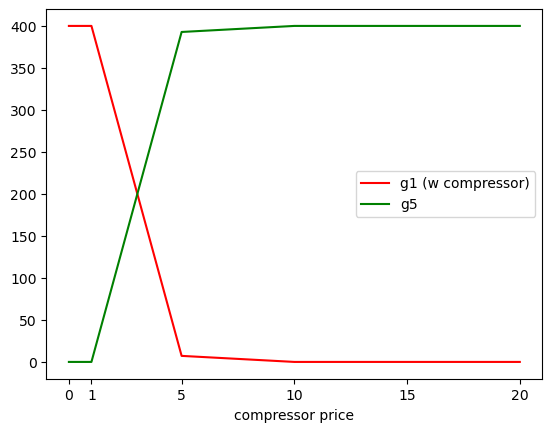

In [9]:
import matplotlib.pyplot as plt

plt.plot([0,1,5, 10, 15, 20],flows_g1, color='red', label='g1 (w compressor)')
plt.plot([0,1,5, 10, 15, 20],flows_g5, color='green', label='g5')

plt.xticks([0,1,5, 10, 15, 20])
plt.xlabel('compressor price')

plt.legend()